In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Lecture (le comment='#' vire les textes inutiles au début)
df = pd.read_csv('data/SH_MTN002037002.csv', sep=';', comment='#')

# 2. Nettoyage automatique des noms de colonnes (vire les espaces)
df.columns = df.columns.str.strip()

# 3. Création d'une vraie colonne Date
# On transforme '195901' en une date que Python comprend
df['DATE'] = pd.to_datetime(df['YYYYMM'].astype(str), format='%Y%m')

# 4. Conversion de la valeur (si c'est en 1/10ème d'unité)
# Vérifie si tu dois diviser par 10 ou pas selon ton fichier
df['VALEUR_PROPRE'] = df['VALEUR'] 

print("✅ Nettoyage terminé !")
df.head()

Matplotlib is building the font cache; this may take a moment.


FileNotFoundError: [Errno 2] No such file or directory: 'data/SH_MTN002037002.csv'

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import glob

sns.set_theme(style="darkgrid")
plt.rcParams['figure.figsize'] = (14, 5)

In [7]:
import glob

# Trouve le premier fichier
fichier_test = glob.glob('data/**/*.csv', recursive=True)[0]
print(f"📄 Fichier : {fichier_test}\n")

# Affiche les 20 premières lignes brutes
with open(fichier_test, 'r', encoding='latin-1') as f:
    for i, ligne in enumerate(f):
        print(f"Ligne {i:2d} | {ligne}", end='')
        if i >= 20:
            break

📄 Fichier : data/vigieau_arretes_2024.csv

Ligne  0 | id,numero,date_debut,date_signature,date_fin,statut,departement,chemin_fichier,niveau_gravite_specifique_aep,ressource_aep_communique,arrete_cadre.id,arrete_cadre.numero,arrete_cadre.date_debut,arrete_cadre.date_fin,arrete_cadre.chemin_fichier,zones_alerte.id,zones_alerte.type,zones_alerte.code,zones_alerte.nom,zones_alerte.niveau_gravite,zones_alerte.id_sandre,regle_gestion,zones_alerte.communes
Ligne  1 | 34627,DDT-BIEF-2023-321-0003 du 17 novembre (ACD LB)),2023-11-18,2023-11-17,2024-01-27,abroge,48,https://regleau.s3.gra.perf.cloud.ovh.net//arrete-restriction/34627/AP7_DDT-BIEF-2023-321-0003_17novembre2023_RAA.odt.pdf,null,null,30330,ACD LB DDT-BIEF 2023-199-0002_18/07/2023,2023-07-20,2024-05-22,https://regleau.s3.gra.perf.cloud.ovh.net//arrete-cadre/30330/AP_DDT_BIEF_2023-199-0002_18072023_VF_RAAcomplet.pdf,"[10954,10956,10955,10953]","[""SUP"",""SUP"",""SUP"",""SUP""]","[""76_48_0010"",""76_48_0012"",""76_48_0011"",""76_48_000

In [6]:
def lire_fichier_meteo(filepath):
    """
    Lit un fichier CSV Météo France qui a des lignes # en en-tête
    Retourne un DataFrame propre
    """
    with open(filepath, 'r', encoding='latin-1') as f:
        lignes = f.readlines()
    
    # Trouve la première ligne qui n'est pas un commentaire
    debut = 0
    for i, ligne in enumerate(lignes):
        if not ligne.startswith('#'):
            debut = i
            break
    
    # Relit proprement à partir de l'en-tête
    df = pd.read_csv(
        filepath,
        sep=';',
        skiprows=debut,
        encoding='latin-1'
    )
    
    # Renomme les colonnes pour plus de clarté
    df.columns = df.columns.str.strip()
    
    # Convertit YYYYMM en vrai datetime
    df['DATE'] = pd.to_datetime(df['YYYYMM'].astype(str), format='%Y%m')
    df['ANNEE'] = df['DATE'].dt.year
    df['MOIS'] = df['DATE'].dt.month
    
    # Remplace les valeurs manquantes (souvent -9999 chez Météo France)
    df['VALEUR'] = pd.to_numeric(df['VALEUR'], errors='coerce')
    df.loc[df['VALEUR'] < -999, 'VALEUR'] = None
    
    return df

# Test sur un fichier
fichier_test = glob.glob('data/**/*.csv', recursive=True)[0]
df_test = lire_fichier_meteo(fichier_test)
print(f"✅ {fichier_test}")
print(df_test.head())
print(f"Période : {df_test['DATE'].min()} → {df_test['DATE'].max()}")

KeyError: 'YYYYMM'

In [8]:
import glob

fichiers = glob.glob('data/**/*.csv', recursive=True)
for f in fichiers:
    print(f)

data/vigieau_arretes_2024.csv
data/stations-meteo-france.csv
data/ch4_mm_gl.csv
data/ademe_projections_4c.csv
data/co2_mm_mlo.csv
data/sdes_ges_namea.csv
data/ademe_projections_2c.csv
data/co2_mm_gl.csv
data/explore2_vcn10_region.csv
data/n2o_mm_gl.csv
data/SH_TX_metropole/SH_MTX276217001.csv
data/SH_TX_metropole/SH_MTX386027001.csv
data/SH_TX_metropole/SH_MTX287106001.csv
data/SH_TX_metropole/SH_MTX044117002.csv
data/SH_TX_metropole/SH_MTX203204001.csv
data/SH_TX_metropole/SH_MTX163223001.csv
data/SH_TX_metropole/SH_MTX226307001.csv
data/SH_TX_metropole/SH_MTX181124001.csv
data/SH_TX_metropole/SH_MTX026324001.csv
data/SH_TX_metropole/SH_MTX236208001.csv
data/SH_TX_metropole/SH_MTX369204002.csv
data/SH_TX_metropole/SH_MTX285216001.csv
data/SH_TX_metropole/SH_MTX104019001.csv
data/SH_TX_metropole/SH_MTX246127001.csv
data/SH_TX_metropole/SH_MTX269264001.csv
data/SH_TX_metropole/SH_MTX171491001.csv
data/SH_TX_metropole/SH_MTX220041001.csv
data/SH_TX_metropole/SH_MTX450020001.csv
data/SH_T

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def lire_co2_noaa(filepath):
    """Lit un fichier CO2 NOAA en ignorant les lignes de commentaires #"""
    with open(filepath, 'r') as f:
        lignes = f.readlines()
    
    # Trouve la ligne d'en-tête (première sans #)
    debut = 0
    for i, ligne in enumerate(lignes):
        if not ligne.startswith('#'):
            debut = i
            break
    
    df = pd.read_csv(filepath, skiprows=debut)
    df.columns = df.columns.str.strip()
    return df

# Charge les deux fichiers — adapte les noms si besoin
df_maunaloa = lire_co2_noaa('data/co2_mm_mlo.csv')   # Mauna Loa (depuis 1958)
df_global   = lire_co2_noaa('data/co2_mm_gl.csv')    # Global (depuis 1979)

print("=== Mauna Loa ===")
print(df_maunaloa.columns.tolist())
print(df_maunaloa.head(2))

print("\n=== Global ===")
print(df_global.columns.tolist())
print(df_global.head(2))

=== Mauna Loa ===
['year', 'month', 'decimal date', 'average', 'deseasonalized', 'ndays', 'sdev', 'unc']
   year  month  decimal date  average  deseasonalized  ndays  sdev   unc
0  1958      3     1958.2027   315.71          314.44     -1 -9.99 -0.99
1  1958      4     1958.2877   317.45          315.16     -1 -9.99 -0.99

=== Global ===
['year', 'month', 'decimal', 'average', 'average_unc', 'trend', 'trend_unc']
   year  month   decimal  average  average_unc   trend  trend_unc
0  1979      1  1979.042   336.56         0.11  335.92       0.09
1  1979      2  1979.125   337.29         0.09  336.26       0.09


In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def lire_noaa(filepath, nom_gaz, unite):
    with open(filepath, 'r') as f:
        lignes = f.readlines()
    
    debut = 0
    for i, ligne in enumerate(lignes):
        if not ligne.startswith('#') and ligne.strip() != '':
            debut = i
            break
    
    df = pd.read_csv(filepath, skiprows=debut)
    df.columns = df.columns.str.strip()
    df = df.rename(columns={'average': 'valeur'})
    
    df['DATE'] = pd.to_datetime(
        df['year'].astype(str) + '-' + df['month'].astype(str),
        format='%Y-%m'
    )
    # Nettoie les valeurs manquantes NOAA
    df.loc[df['valeur'] < 0, 'valeur'] = None
    
    df['gaz']   = nom_gaz
    df['unite'] = unite
    
    return df[['DATE', 'year', 'month', 'valeur', 'gaz', 'unite']]


# Charge les 3 fichiers — adapte les noms si besoin
df_co2 = lire_noaa('data/co2_mm_gl.csv', 'CO2',  'ppm')
df_ch4 = lire_noaa('data/ch4_mm_gl.csv', 'CH4',  'ppb')
df_n2o = lire_noaa('data/n2o_mm_gl.csv', 'N2O',  'ppb')

# Combine en une seule table "longue"
df_ges = pd.concat([df_co2, df_ch4, df_n2o], ignore_index=True).sort_values(['gaz', 'DATE'])

print(f"✅ Table combinée : {len(df_ges)} lignes")
print(f"\nRésumé par gaz :")
print(df_ges.groupby('gaz').agg(
    debut=('DATE', 'min'),
    fin=('DATE', 'max'),
    nb_mois=('valeur', 'count'),
    derniere_valeur=('valeur', 'last')
).to_string())


✅ Table combinée : 1372 lignes

Résumé par gaz :
         debut        fin  nb_mois  derniere_valeur
gaz                                                
CH4 1983-07-01 2025-11-01      509          1945.85
CO2 1979-01-01 2025-12-01      564           427.35
N2O 2001-01-01 2025-11-01      299           339.46


In [11]:
# Format large : une ligne par date, une colonne par gaz
df_large = df_ges.pivot_table(
    index='DATE', 
    columns='gaz', 
    values='valeur'
).reset_index()

df_large.columns.name = None  # Enlève le nom de l'index
df_large = df_large.rename(columns={
    'CO2': 'CO2_ppm',
    'CH4': 'CH4_ppb',
    'N2O': 'N2O_ppb'
})

# Sauvegarde
df_large.to_csv('data/ges_combines.csv', index=False)

print("✅ Table large sauvegardée → data/ges_combines.csv")
print(f"   Période commune : {df_large.dropna()['DATE'].min()} → {df_large.dropna()['DATE'].max()}")
print(f"   {len(df_large.dropna())} mois avec les 3 gaz disponibles")
df_large.tail(5)

✅ Table large sauvegardée → data/ges_combines.csv
   Période commune : 2001-01-01 00:00:00 → 2025-11-01 00:00:00
   299 mois avec les 3 gaz disponibles


,DATE,CH4_ppb,CO2_ppm,N2O_ppb
559,2025-08-01,1930.61,423.04,338.88
560,2025-09-01,1939.45,423.15,338.99
561,2025-10-01,1946.16,424.72,339.21
562,2025-11-01,1945.85,426.47,339.46
563,2025-12-01,NaN,427.35,NaN


/var/folders/1m/b1tgmj252qxb80_71bh1dgbm0000gn/T/ipykernel_42455/425791240.py:41: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/1m/b1tgmj252qxb80_71bh1dgbm0000gn/T/ipykernel_42455/425791240.py:41: UserWarning: Glyph 127757 (\N{EARTH GLOBE EUROPE-AFRICA}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/1m/b1tgmj252qxb80_71bh1dgbm0000gn/T/ipykernel_42455/425791240.py:41: UserWarning: Glyph 8324 (\N{SUBSCRIPT FOUR}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/1m/b1tgmj252qxb80_71bh1dgbm0000gn/T/ipykernel_42455/425791240.py:42: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.savefig('data/ges_3gaz.png', dpi=150)
/var/folders/1m/b1tgmj252qxb80_71bh1dgbm0000gn/T/ipykernel_42455/425791240.py:42: UserWarning: Glyph 127757 (\N{EARTH GLOBE EUROPE-AFRICA}) missing from font(s) Arial.
  plt.savefig('data/ges_3gaz.png', dpi=150)
/var/folders/1m/b1tgmj252qxb80_71bh1dgbm0000gn/T/i

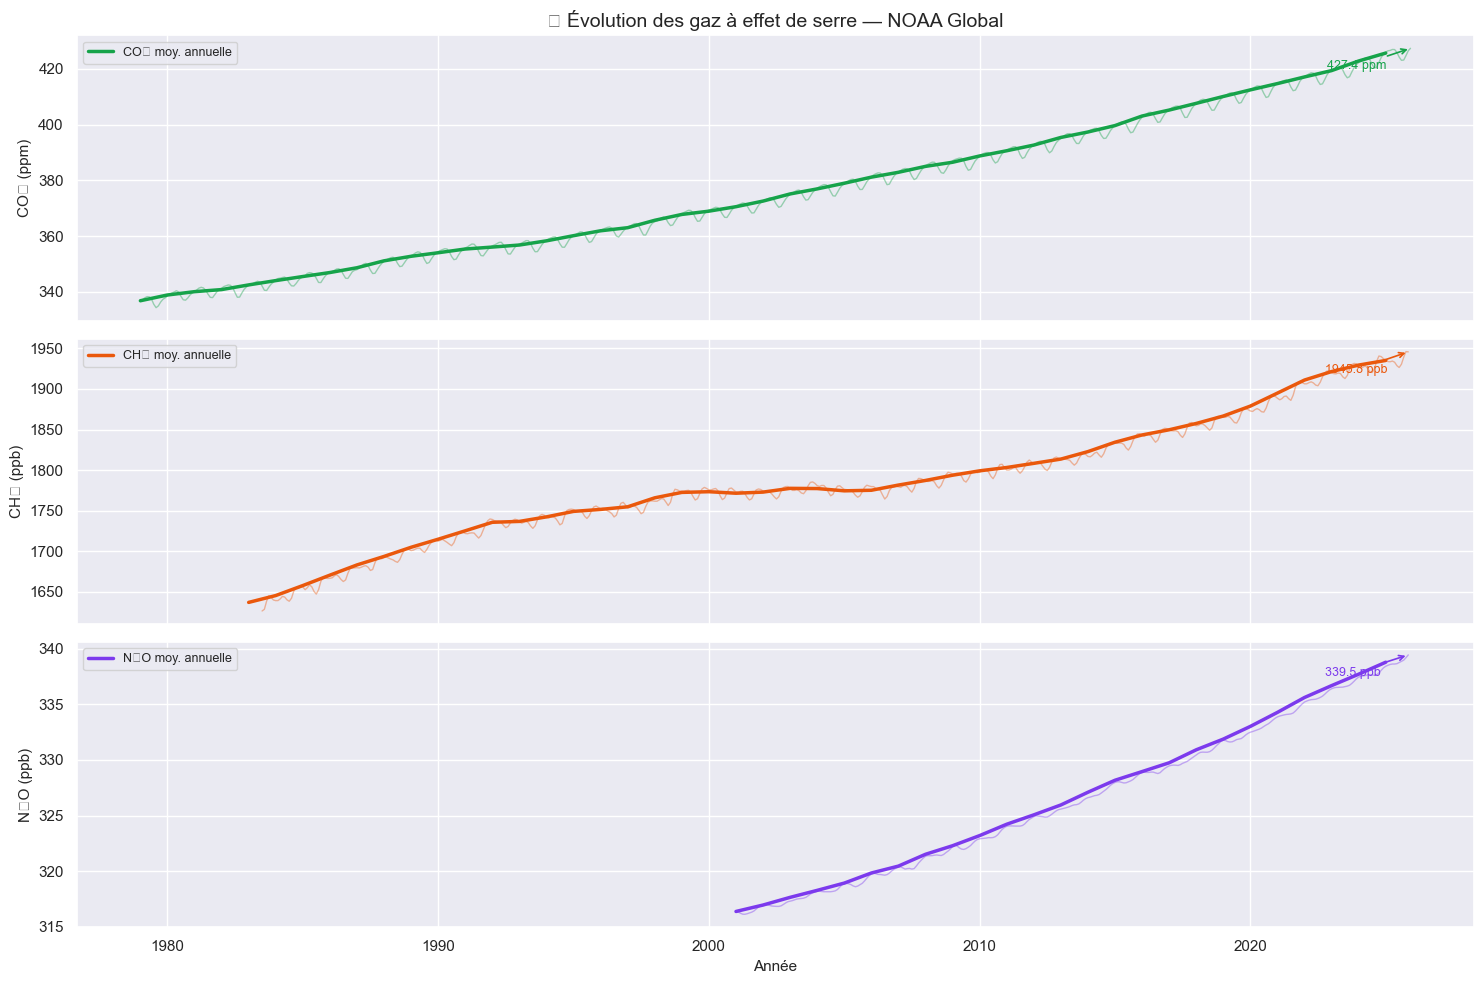

✅ Graphique sauvegardé → data/ges_3gaz.png


In [12]:
sns.set_theme(style="darkgrid")
fig, axes = plt.subplots(3, 1, figsize=(15, 10), sharex=True)

configs = [
    ('CO2_ppm', 'CO₂',  '#16a34a', 'ppm'),
    ('CH4_ppb', 'CH₄',  '#ea580c', 'ppb'),
    ('N2O_ppb', 'N₂O',  '#7c3aed', 'ppb'),
]

for ax, (col, label, couleur, unite) in zip(axes, configs):
    donnees = df_large.dropna(subset=[col])
    
    # Courbe mensuelle
    ax.plot(donnees['DATE'], donnees[col],
            color=couleur, linewidth=1, alpha=0.4)
    
    # Moyenne annuelle
    ann = donnees.copy()
    ann['year'] = ann['DATE'].dt.year
    ann_moy = ann.groupby('year')[col].mean().reset_index()
    ax.plot(
        pd.to_datetime(ann_moy['year'].astype(str)),
        ann_moy[col],
        color=couleur, linewidth=2.5, label=f'{label} moy. annuelle'
    )
    
    ax.set_ylabel(f'{label} ({unite})', fontsize=11)
    ax.legend(loc='upper left', fontsize=9)
    
    # Valeur actuelle en annotation
    derniere = donnees[col].dropna().iloc[-1]
    ax.annotate(f'{derniere:.1f} {unite}',
                xy=(donnees['DATE'].iloc[-1], derniere),
                xytext=(-60, -15), textcoords='offset points',
                fontsize=9, color=couleur,
                arrowprops=dict(arrowstyle='->', color=couleur, lw=1.2))

axes[0].set_title('🌍 Évolution des gaz à effet de serre — NOAA Global', fontsize=14)
axes[2].set_xlabel('Année', fontsize=11)

plt.tight_layout()
plt.savefig('data/ges_3gaz.png', dpi=150)
plt.show()
print("✅ Graphique sauvegardé → data/ges_3gaz.png")

/var/folders/1m/b1tgmj252qxb80_71bh1dgbm0000gn/T/ipykernel_42455/3577023077.py:121: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/1m/b1tgmj252qxb80_71bh1dgbm0000gn/T/ipykernel_42455/3577023077.py:121: UserWarning: Glyph 127807 (\N{HERB}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/1m/b1tgmj252qxb80_71bh1dgbm0000gn/T/ipykernel_42455/3577023077.py:121: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/1m/b1tgmj252qxb80_71bh1dgbm0000gn/T/ipykernel_42455/3577023077.py:121: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/1m/b1tgmj252qxb80_71bh1dgbm0000gn/T/ipykernel_42455/3577023077.py:121: UserWarning: Glyph 128680 (\N{POLICE CARS REVOLVING LIGHT}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/1m/b1tgmj252qxb80_71bh1dgbm0000gn/T/ipykernel_42455/3577023077.py:121: UserWarning: G

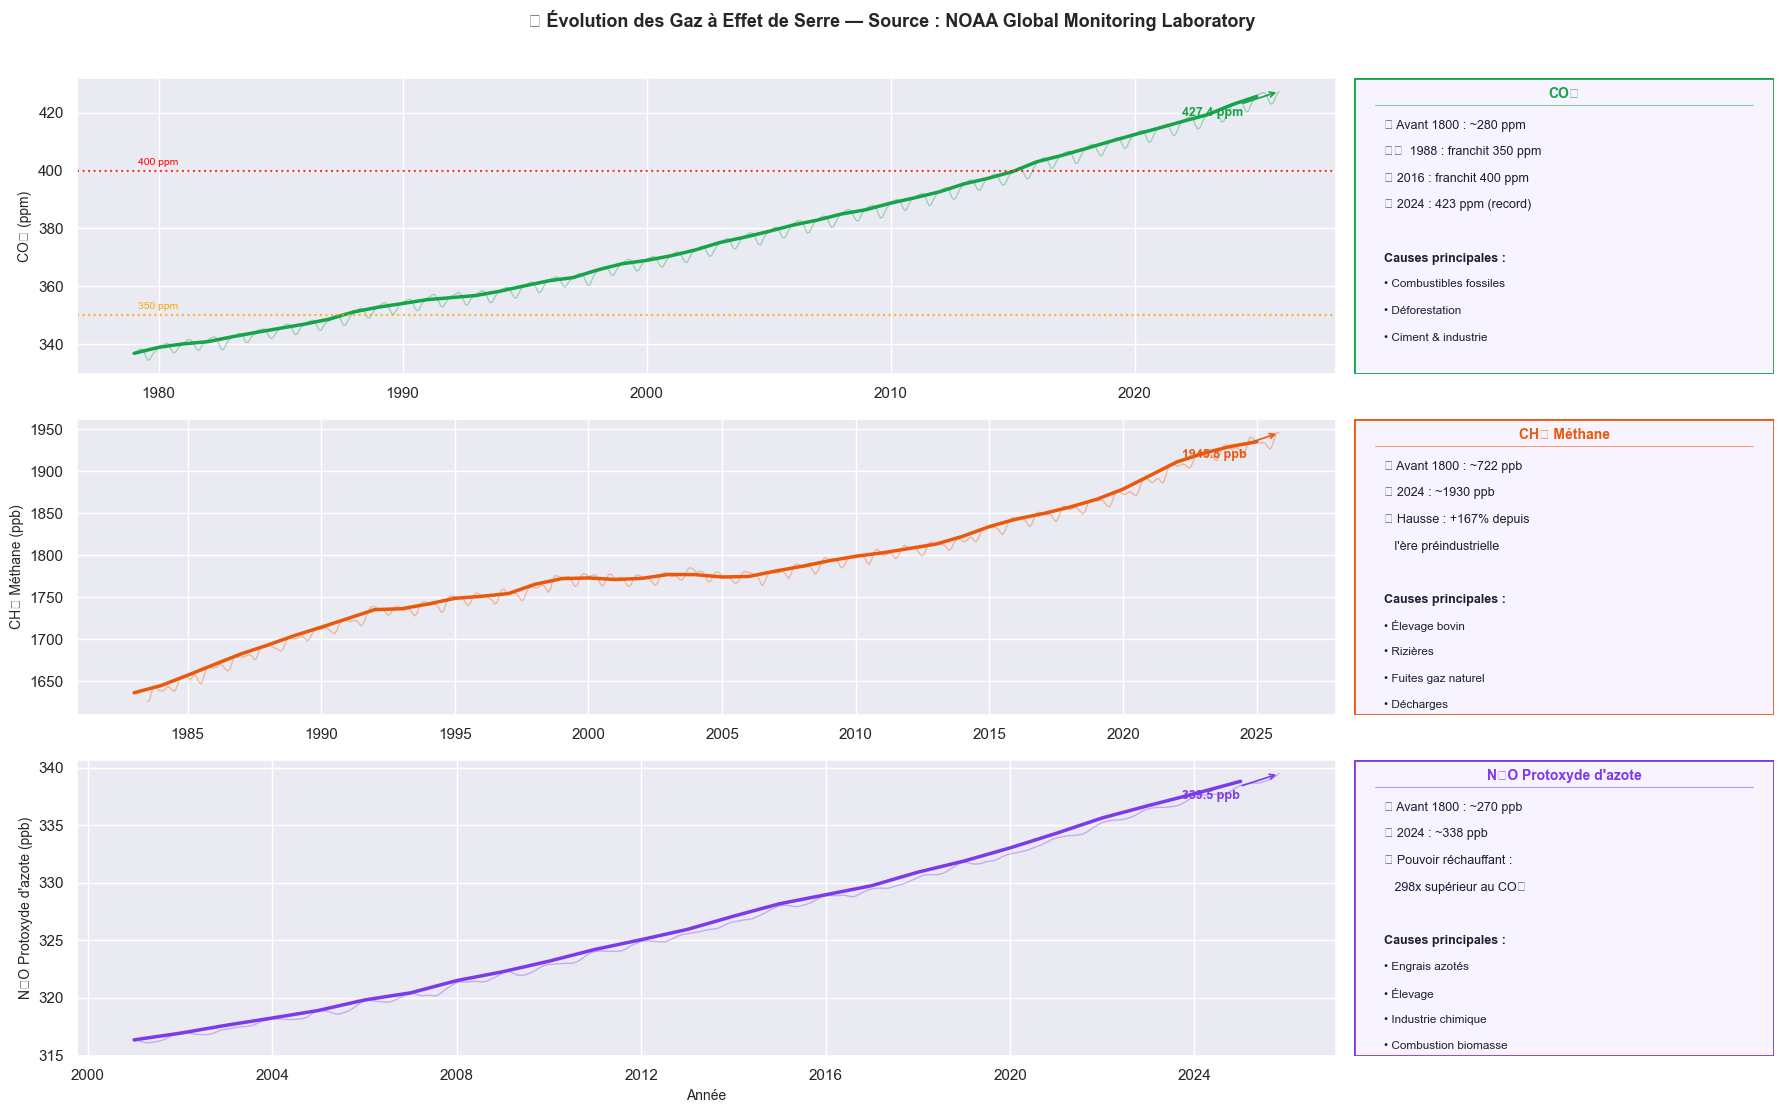

✅ Sauvegardé → data/ges_3gaz_contexte.png


In [15]:
sns.set_theme(style="darkgrid")
fig, axes = plt.subplots(3, 2, figsize=(18, 11),
                          gridspec_kw={'width_ratios': [3, 1]})

configs = [
    ('CO2_ppm', 'CO₂', '#16a34a', 'ppm', [
        "🌿 Avant 1800 : ~280 ppm",
        "⚠️  1988 : franchit 350 ppm",
        "🚨 2016 : franchit 400 ppm",
        "📍 2024 : 423 ppm (record)",
        "",
        "Causes principales :",
        "• Combustibles fossiles",
        "• Déforestation",
        "• Ciment & industrie",
    ]),
    ('CH4_ppb', 'CH₄ Méthane', '#ea580c', 'ppb', [
        "🌿 Avant 1800 : ~722 ppb",
        "📍 2024 : ~1930 ppb",
        "📈 Hausse : +167% depuis",
        "   l'ère préindustrielle",
        "",
        "Causes principales :",
        "• Élevage bovin",
        "• Rizières",
        "• Fuites gaz naturel",
        "• Décharges",
    ]),
    ('N2O_ppb', 'N₂O Protoxyde d\'azote', '#7c3aed', 'ppb', [
        "🌿 Avant 1800 : ~270 ppb",
        "📍 2024 : ~338 ppb",
        "⚡ Pouvoir réchauffant :",
        "   298x supérieur au CO₂",
        "",
        "Causes principales :",
        "• Engrais azotés",
        "• Élevage",
        "• Industrie chimique",
        "• Combustion biomasse",
    ]),
]

for i, (col, label, couleur, unite, contexte) in enumerate(configs):
    ax_graph = axes[i][0]
    ax_text  = axes[i][1]

    # ── Graphique ──
    donnees = df_large.dropna(subset=[col])
    ax_graph.plot(donnees['DATE'], donnees[col],
                  color=couleur, linewidth=1, alpha=0.35)
    
    ann = donnees.copy()
    ann['year'] = ann['DATE'].dt.year
    ann_moy = ann.groupby('year')[col].mean().reset_index()
    ax_graph.plot(
        pd.to_datetime(ann_moy['year'].astype(str)),
        ann_moy[col],
        color=couleur, linewidth=2.5
    )

    # Seuils CO2
    if col == 'CO2_ppm':
        ax_graph.axhline(350, color='orange', linestyle=':', linewidth=1.5, alpha=0.8)
        ax_graph.axhline(400, color='red',    linestyle=':', linewidth=1.5, alpha=0.8)
        ax_graph.text(donnees['DATE'].iloc[2], 352, '350 ppm', fontsize=7.5, color='orange')
        ax_graph.text(donnees['DATE'].iloc[2], 402, '400 ppm', fontsize=7.5, color='red')

    # Annotation dernière valeur
    derniere = donnees[col].dropna().iloc[-1]
    ax_graph.annotate(
        f'{derniere:.1f} {unite}',
        xy=(donnees['DATE'].iloc[-1], derniere),
        xytext=(-70, -18), textcoords='offset points',
        fontsize=9, color=couleur, fontweight='bold',
        arrowprops=dict(arrowstyle='->', color=couleur, lw=1.2)
    )

    ax_graph.set_ylabel(f'{label} ({unite})', fontsize=10)
    if i == 2:
        ax_graph.set_xlabel('Année', fontsize=10)

    # ── Panneau texte ──
    ax_text.axis('off')
    ax_text.set_facecolor('#f8f4ff')

    # Cadre coloré
    rect = plt.Rectangle((0, 0), 1, 1,
                           transform=ax_text.transAxes,
                           facecolor='#f8f4ff',
                           edgecolor=couleur, linewidth=2)
    ax_text.add_patch(rect)

    # Titre du panneau
    ax_text.text(0.5, 0.97, label,
                 transform=ax_text.transAxes,
                 fontsize=10, fontweight='bold', color=couleur,
                 ha='center', va='top')

# Ligne séparatrice
    ax_text.axhline(y=0.91, xmin=0.05, xmax=0.95,
                    color=couleur, linewidth=0.8, alpha=0.5)

    # Texte de contexte
    y_pos = 0.86
    for ligne in contexte:
        style = 'bold' if ligne.startswith('Causes') else 'normal'
        size  = 8.5 if ligne.startswith('•') or ligne == '' else 9
        ax_text.text(0.07, y_pos, ligne,
                     transform=ax_text.transAxes,
                     fontsize=size, fontstyle='normal',
                     fontweight=style,
                     color='#1e1e2e', va='top')
        y_pos -= 0.09

# ── Titre global ──
fig.suptitle(
    '🌍 Évolution des Gaz à Effet de Serre — Source : NOAA Global Monitoring Laboratory',
    fontsize=13, fontweight='bold', y=1.01
)

plt.tight_layout()
plt.savefig('data/ges_3gaz_contexte.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Sauvegardé → data/ges_3gaz_contexte.png")

In [16]:
import pandas as pd
import os
from glob import glob

# ── Dossier températures maximales ──
folder_path = "data/SH_TX_metropole"

# Liste de tous les fichiers CSV
csv_files = glob(os.path.join(folder_path, "*.csv"))
print(f"📂 {len(csv_files)} fichiers trouvés dans {folder_path}")

all_data = []
for file in csv_files:
    df = pd.read_csv(file, sep=";", comment="#")
    df.columns = df.columns.str.strip()
    # Garde seulement les colonnes utiles
    all_data.append(df[["YYYYMM", "VALEUR"]])

# Concatène toutes les stations
df_all = pd.concat(all_data, ignore_index=True)

# Nettoie les valeurs manquantes Météo France (-9999)
df_all["VALEUR"] = pd.to_numeric(df_all["VALEUR"], errors="coerce")
df_all.loc[df_all["VALEUR"] < -999, "VALEUR"] = None
df_all = df_all.dropna(subset=["VALEUR"])

# ── Moyenne des TX par mois (toutes stations) ──
df_mean_mois = df_all.groupby("YYYYMM", as_index=False)["VALEUR"].mean()
df_mean_mois.to_csv("data/tx_moyenne_par_mois.csv", index=False, sep=";")
print(f"✅ CSV généré : data/tx_moyenne_par_mois.csv")
print(df_mean_mois.head())

# ── Moyenne des TX maximales par année ──
df_mean_mois["YYYY"] = df_mean_mois["YYYYMM"].astype(str).str[:4].astype(int)

# Filtre années cohérentes
df_mean_mois = df_mean_mois[
    (df_mean_mois["YYYY"] >= 1900) &
    (df_mean_mois["YYYY"] <= 2025)
]

# MAX des moyennes mensuelles par année = température max annuelle
df_yearly_max = df_mean_mois.groupby("YYYY", as_index=False)["VALEUR"].max()
df_yearly_max = df_yearly_max.rename(columns={"VALEUR": "TX_MAX_ANNUELLE"})

df_yearly_max.to_csv("data/tx_max_par_annee.csv", index=False, sep=";")
print(f"\n✅ CSV généré : data/tx_max_par_annee.csv")
print(df_yearly_max.tail(10))

# ── Résumé ──
print(f"\n📊 Résumé :")
print(f"   Période : {df_yearly_max['YYYY'].min()} → {df_yearly_max['YYYY'].max()}")
print(f"   TX max historique : {df_yearly_max['TX_MAX_ANNUELLE'].max():.1f}°C en {df_yearly_max.loc[df_yearly_max['TX_MAX_ANNUELLE'].idxmax(), 'YYYY']}")
print(f"   TX max récente    : {df_yearly_max.tail(5)[['YYYY','TX_MAX_ANNUELLE']].to_string(index=False)}")

📂 321 fichiers trouvés dans data/SH_TX_metropole
✅ CSV généré : data/tx_moyenne_par_mois.csv
   YYYYMM     VALEUR
0  195101   7.166279
1  195102   7.558140
2  195103   9.055814
3  195104  13.558140
4  195105  15.556977

✅ CSV généré : data/tx_max_par_annee.csv
    YYYY  TX_MAX_ANNUELLE
64  2015        28.227103
65  2016        26.995950
66  2017        26.384112
67  2018        28.442679
68  2019        28.410592
69  2020        27.759190
70  2021        24.776636
71  2022        29.301558
72  2023        26.796226
73  2024        27.682019

📊 Résumé :
   Période : 1951 → 2024
   TX max historique : 30.7°C en 2003
   TX max récente    :  YYYY  TX_MAX_ANNUELLE
 2020        27.759190
 2021        24.776636
 2022        29.301558
 2023        26.796226
 2024        27.682019


📂 321 fichiers trouvés
✅ CSV générés dans data/

📊 Résumé :
   Période       : 1951 → 2024
   Record absolu : 30.7°C en 2003
   5 dernières années :
 YYYY  TX_MAX_ANNUELLE
 2020        27.759190
 2021        24.776636
 2022        29.301558
 2023        26.796226
 2024        27.682019


/var/folders/1m/b1tgmj252qxb80_71bh1dgbm0000gn/T/ipykernel_4495/3495154513.py:69: UserWarning: Glyph 127777 (\N{THERMOMETER}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/1m/b1tgmj252qxb80_71bh1dgbm0000gn/T/ipykernel_4495/3495154513.py:69: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/1m/b1tgmj252qxb80_71bh1dgbm0000gn/T/ipykernel_4495/3495154513.py:70: UserWarning: Glyph 127777 (\N{THERMOMETER}) missing from font(s) Arial.
  plt.savefig("data/tx_max_annuelle.png", dpi=150)
/var/folders/1m/b1tgmj252qxb80_71bh1dgbm0000gn/T/ipykernel_4495/3495154513.py:70: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) Arial.
  plt.savefig("data/tx_max_annuelle.png", dpi=150)
/Users/matteocherief/Desktop/hackathon_data_sdv/venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 127777 (\N{THERMOMETER}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, 

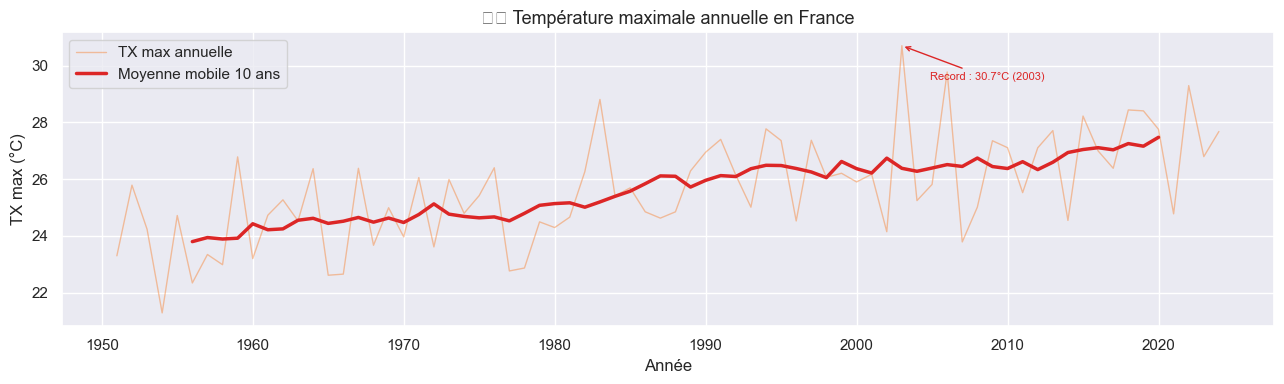

✅ Graphique sauvegardé → data/tx_max_annuelle.png


In [2]:
# src/tx_max.py
import pandas as pd
import os
from glob import glob
import matplotlib.pyplot as plt
import seaborn as sns

# ── Chargement ──
folder_path = "data/SH_TX_metropole"
csv_files = glob(os.path.join(folder_path, "*.csv"))
print(f"📂 {len(csv_files)} fichiers trouvés")

all_data = []
for file in csv_files:
    df = pd.read_csv(file, sep=";", comment="#")
    df.columns = df.columns.str.strip()
    all_data.append(df[["YYYYMM", "VALEUR"]])

df_all = pd.concat(all_data, ignore_index=True)

# ── Nettoyage ──
df_all["VALEUR"] = pd.to_numeric(df_all["VALEUR"], errors="coerce")
df_all.loc[df_all["VALEUR"] < -999, "VALEUR"] = None
df_all = df_all.dropna(subset=["VALEUR"])

# ── Moyenne mensuelle toutes stations ──
df_mois = df_all.groupby("YYYYMM", as_index=False)["VALEUR"].mean()
df_mois["YYYY"] = df_mois["YYYYMM"].astype(str).str[:4].astype(int)
df_mois = df_mois[(df_mois["YYYY"] >= 1900) & (df_mois["YYYY"] <= 2025)]

# ── TX max annuelle ──
df_annee = df_mois.groupby("YYYY", as_index=False)["VALEUR"].max()
df_annee = df_annee.rename(columns={"VALEUR": "TX_MAX_ANNUELLE"})
df_annee["MOY_10"] = df_annee["TX_MAX_ANNUELLE"].rolling(10, center=True).mean()

# ── Export CSV ──
df_mois.to_csv("data/tx_moyenne_par_mois.csv",  index=False, sep=";")
df_annee.to_csv("data/tx_max_par_annee.csv", index=False, sep=";")
print("✅ CSV générés dans data/")

# ── Résumé ──
idx_max = df_annee["TX_MAX_ANNUELLE"].idxmax()
print(f"\n📊 Résumé :")
print(f"   Période       : {df_annee['YYYY'].min()} → {df_annee['YYYY'].max()}")
print(f"   Record absolu : {df_annee.loc[idx_max, 'TX_MAX_ANNUELLE']:.1f}°C en {df_annee.loc[idx_max, 'YYYY']}")
print(f"   5 dernières années :\n{df_annee.tail(5)[['YYYY','TX_MAX_ANNUELLE']].to_string(index=False)}")

# ── Visualisation ──
sns.set_theme(style="darkgrid")
fig, ax = plt.subplots(figsize=(13, 4))

ax.plot(df_annee["YYYY"], df_annee["TX_MAX_ANNUELLE"],
        color="#f97316", linewidth=1, alpha=0.4, label="TX max annuelle")
ax.plot(df_annee["YYYY"], df_annee["MOY_10"],
        color="#dc2626", linewidth=2.5, label="Moyenne mobile 10 ans")

ax.annotate(
    f"Record : {df_annee.loc[idx_max, 'TX_MAX_ANNUELLE']:.1f}°C ({df_annee.loc[idx_max, 'YYYY']})",
    xy=(df_annee.loc[idx_max, "YYYY"], df_annee.loc[idx_max, "TX_MAX_ANNUELLE"]),
    xytext=(20, -25), textcoords="offset points",
    fontsize=8, color="#dc2626",
    arrowprops=dict(arrowstyle="->", color="#dc2626")
)

ax.set_title("🌡️ Température maximale annuelle en France", fontsize=13)
ax.set_xlabel("Année")
ax.set_ylabel("TX max (°C)")
ax.legend()
plt.tight_layout()
plt.savefig("data/tx_max_annuelle.png", dpi=150)
plt.show()
print("✅ Graphique sauvegardé → data/tx_max_annuelle.png")

✅ CSV généré → data/empreinte_carbone_par_habitant.csv

📊 Résumé :
   Période       : 1990 → 2024
   Maximum       : 13.3 tCO2e en 2010
   Minimum       : 8.2 tCO2e en 2024
   Baisse totale : -3.9 tCO2e (32% de réduction)
   Objectif 2050 : 2 tCO2e/hab (neutralité carbone)


/var/folders/1m/b1tgmj252qxb80_71bh1dgbm0000gn/T/ipykernel_4495/2979997643.py:119: UserWarning: Glyph 127757 (\N{EARTH GLOBE EUROPE-AFRICA}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/1m/b1tgmj252qxb80_71bh1dgbm0000gn/T/ipykernel_4495/2979997643.py:119: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/1m/b1tgmj252qxb80_71bh1dgbm0000gn/T/ipykernel_4495/2979997643.py:120: UserWarning: Glyph 127757 (\N{EARTH GLOBE EUROPE-AFRICA}) missing from font(s) Arial.
  plt.savefig("data/empreinte_carbone.png", dpi=150)
/var/folders/1m/b1tgmj252qxb80_71bh1dgbm0000gn/T/ipykernel_4495/2979997643.py:120: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) Arial.
  plt.savefig("data/empreinte_carbone.png", dpi=150)
/Users/matteocherief/Desktop/hackathon_data_sdv/venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 127757 (\N{EARTH GLOBE EUROPE-AFRICA}) missing from font(s) Arial.
  fig.

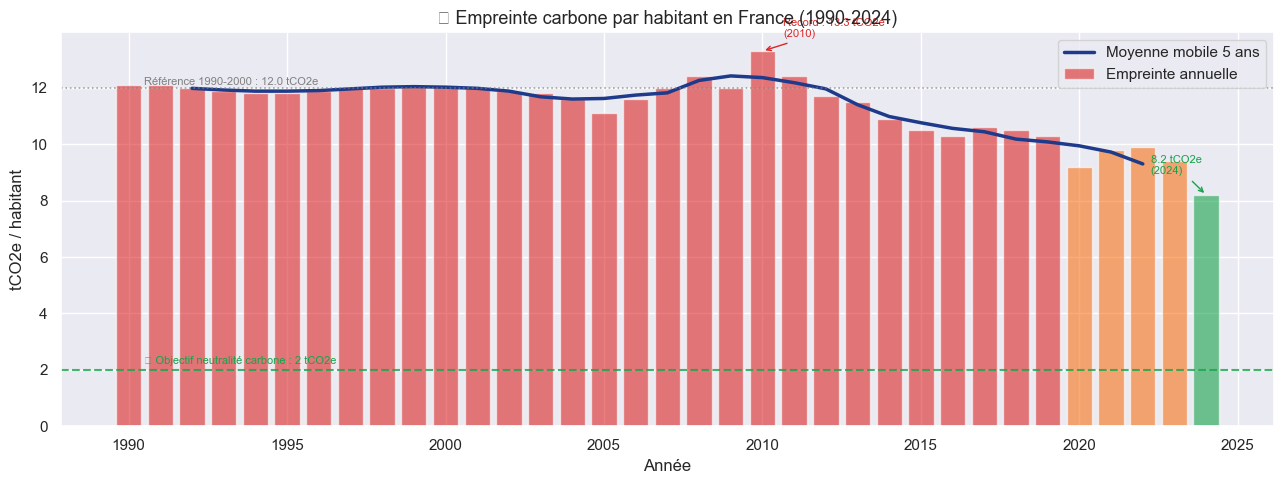

✅ Graphique sauvegardé → data/empreinte_carbone.png


In [3]:
# src/empreinte_carbone.py
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import io

# ── Données intégrées directement ──
data = """annee,empreinte_carbone_tCO2e_par_habitant
1990,12.1
1991,12.1
1992,12.0
1993,11.9
1994,11.8
1995,11.8
1996,11.9
1997,12.0
1998,12.0
1999,12.1
2000,12.1
2001,12.0
2002,11.9
2003,11.8
2004,11.6
2005,11.1
2006,11.6
2007,12.0
2008,12.4
2009,12.0
2010,13.3
2011,12.4
2012,11.7
2013,11.5
2014,10.9
2015,10.5
2016,10.3
2017,10.6
2018,10.5
2019,10.3
2020,9.2
2021,9.8
2022,9.9
2023,9.4
2024,8.2"""

# ── Chargement ──
df = pd.read_csv(io.StringIO(data))
df.columns = df.columns.str.strip()
df = df.rename(columns={
    "annee": "YYYY",
    "empreinte_carbone_tCO2e_par_habitant": "EMPREINTE_TCO2E"
})

# ── Calculs ──
df["MOY_5"] = df["EMPREINTE_TCO2E"].rolling(5, center=True).mean()
baisse_totale = df["EMPREINTE_TCO2E"].iloc[0] - df["EMPREINTE_TCO2E"].iloc[-1]
baisse_pct    = (baisse_totale / df["EMPREINTE_TCO2E"].iloc[0]) * 100
idx_max       = df["EMPREINTE_TCO2E"].idxmax()
idx_min       = df["EMPREINTE_TCO2E"].idxmin()

# ── Export CSV ──
df.to_csv("data/empreinte_carbone_par_habitant.csv", index=False, sep=";")
print("✅ CSV généré → data/empreinte_carbone_par_habitant.csv")

# ── Résumé ──
print(f"\n📊 Résumé :")
print(f"   Période       : {df['YYYY'].min()} → {df['YYYY'].max()}")
print(f"   Maximum       : {df.loc[idx_max, 'EMPREINTE_TCO2E']:.1f} tCO2e en {df.loc[idx_max, 'YYYY']}")
print(f"   Minimum       : {df.loc[idx_min, 'EMPREINTE_TCO2E']:.1f} tCO2e en {df.loc[idx_min, 'YYYY']}")
print(f"   Baisse totale : -{baisse_totale:.1f} tCO2e ({baisse_pct:.0f}% de réduction)")
print(f"   Objectif 2050 : 2 tCO2e/hab (neutralité carbone)")

# ── Visualisation ──
sns.set_theme(style="darkgrid")
fig, ax = plt.subplots(figsize=(13, 5))

# Barres
couleurs = ["#dc2626" if v > 10 else "#f97316" if v > 9 else "#16a34a"
            for v in df["EMPREINTE_TCO2E"]]
ax.bar(df["YYYY"], df["EMPREINTE_TCO2E"],
       color=couleurs, alpha=0.6, label="Empreinte annuelle")

# Moyenne mobile
ax.plot(df["YYYY"], df["MOY_5"],
        color="#1e3a8a", linewidth=2.5, label="Moyenne mobile 5 ans")

# Ligne objectif 2050
ax.axhline(2, color="#16a34a", linestyle="--", linewidth=1.5, alpha=0.8)
ax.text(1990.5, 2.2, "🎯 Objectif neutralité carbone : 2 tCO2e",
        fontsize=8, color="#16a34a")

# Ligne moyenne 1990
ref = df[df["YYYY"] <= 2000]["EMPREINTE_TCO2E"].mean()
ax.axhline(ref, color="gray", linestyle=":", linewidth=1.2, alpha=0.7)
ax.text(1990.5, ref + 0.1, f"Référence 1990-2000 : {ref:.1f} tCO2e",
        fontsize=8, color="gray")

# Annotation record
ax.annotate(
    f"Record : {df.loc[idx_max, 'EMPREINTE_TCO2E']:.1f} tCO2e\n({df.loc[idx_max, 'YYYY']})",
    xy=(df.loc[idx_max, "YYYY"], df.loc[idx_max, "EMPREINTE_TCO2E"]),
    xytext=(15, 10), textcoords="offset points",
    fontsize=8, color="#dc2626",
    arrowprops=dict(arrowstyle="->", color="#dc2626")
)

# Annotation dernière valeur
ax.annotate(
    f"{df['EMPREINTE_TCO2E'].iloc[-1]:.1f} tCO2e\n({df['YYYY'].iloc[-1]})",
    xy=(df["YYYY"].iloc[-1], df["EMPREINTE_TCO2E"].iloc[-1]),
    xytext=(-40, 15), textcoords="offset points",
    fontsize=8, color="#16a34a",
    arrowprops=dict(arrowstyle="->", color="#16a34a")
)

ax.set_title("🌍 Empreinte carbone par habitant en France (1990-2024)", fontsize=13)
ax.set_xlabel("Année")
ax.set_ylabel("tCO2e / habitant")
ax.legend()
plt.tight_layout()
plt.savefig("data/empreinte_carbone.png", dpi=150)
plt.show()
print("✅ Graphique sauvegardé → data/empreinte_carbone.png")

/var/folders/1m/b1tgmj252qxb80_71bh1dgbm0000gn/T/ipykernel_4495/3431183535.py:113: UserWarning: Glyph 127757 (\N{EARTH GLOBE EUROPE-AFRICA}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/1m/b1tgmj252qxb80_71bh1dgbm0000gn/T/ipykernel_4495/3431183535.py:113: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/1m/b1tgmj252qxb80_71bh1dgbm0000gn/T/ipykernel_4495/3431183535.py:114: UserWarning: Glyph 127757 (\N{EARTH GLOBE EUROPE-AFRICA}) missing from font(s) Arial.
  plt.savefig("data/empreinte_carbone_propre.png", dpi=150, bbox_inches='tight')
/var/folders/1m/b1tgmj252qxb80_71bh1dgbm0000gn/T/ipykernel_4495/3431183535.py:114: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) Arial.
  plt.savefig("data/empreinte_carbone_propre.png", dpi=150, bbox_inches='tight')
/Users/matteocherief/Desktop/hackathon_data_sdv/venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 127757 (\N{EARTH 

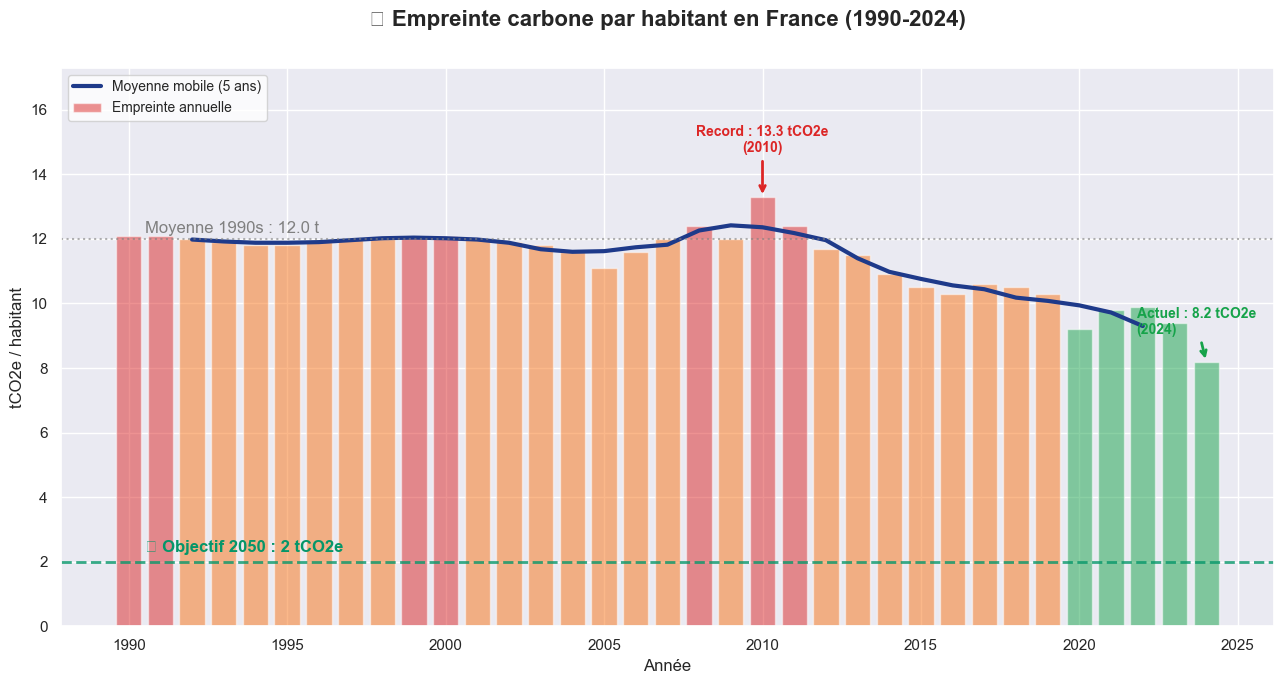

✅ Graphique généré avec succès !


In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import io

# ── 1. Données intégrées ──
data = """annee,empreinte_carbone_tCO2e_par_habitant
1990,12.1
1991,12.1
1992,12.0
1993,11.9
1994,11.8
1995,11.8
1996,11.9
1997,12.0
1998,12.0
1999,12.1
2000,12.1
2001,12.0
2002,11.9
2003,11.8
2004,11.6
2005,11.1
2006,11.6
2007,12.0
2008,12.4
2009,12.0
2010,13.3
2011,12.4
2012,11.7
2013,11.5
2014,10.9
2015,10.5
2016,10.3
2017,10.6
2018,10.5
2019,10.3
2020,9.2
2021,9.8
2022,9.9
2023,9.4
2024,8.2"""

# ── 2. Chargement et Nettoyage ──
df = pd.read_csv(io.StringIO(data))
df.columns = df.columns.str.strip()
df = df.rename(columns={
    "annee": "YYYY",
    "empreinte_carbone_tCO2e_par_habitant": "EMPREINTE_TCO2E"
})

# ── 3. Calculs ──
df["MOY_5"] = df["EMPREINTE_TCO2E"].rolling(5, center=True).mean()
idx_max = df["EMPREINTE_TCO2E"].idxmax()
idx_min = df["EMPREINTE_TCO2E"].idxmin()
ref_1990 = df[df["YYYY"] <= 2000]["EMPREINTE_TCO2E"].mean()

# ── 4. Visualisation Optimisée ──
sns.set_theme(style="darkgrid")
# Augmentation de la hauteur de la figure pour plus d'espace vertical
fig, ax = plt.subplots(figsize=(13, 7)) 

# Couleurs conditionnelles
couleurs = ["#dc2626" if v > 12 else "#f97316" if v > 10 else "#16a34a" for v in df["EMPREINTE_TCO2E"]]

# Barres et Courbe
ax.bar(df["YYYY"], df["EMPREINTE_TCO2E"], color=couleurs, alpha=0.5, label="Empreinte annuelle")
ax.plot(df["YYYY"], df["MOY_5"], color="#1e3a8a", linewidth=3, label="Moyenne mobile (5 ans)")

# --- AJUSTEMENTS DE L'ESPACE (RÉPONSE À TA QUESTION) ---

# 1. On monte le plafond du graphique (Y max + 4) pour éviter la collision avec le titre
ax.set_ylim(0, df["EMPREINTE_TCO2E"].max() + 4)

# 2. On écarte le titre du cadre du graphique
ax.set_title("🌍 Empreinte carbone par habitant en France (1990-2024)", 
             fontsize=16, fontweight='bold', pad=30) 

# 3. Légende placée en haut à gauche pour libérer l'espace central
ax.legend(loc='upper left', frameon=True, facecolor='white', ncol=1, fontsize=10)

# 4. Annotation du Record (centrée et décalée vers le haut)
ax.annotate(
    f"Record : {df.loc[idx_max, 'EMPREINTE_TCO2E']:.1f} tCO2e\n({int(df.loc[idx_max, 'YYYY'])})",
    xy=(df.loc[idx_max, "YYYY"], df.loc[idx_max, "EMPREINTE_TCO2E"]),
    xytext=(0, 30), # Décalage vertical de 30 points
    textcoords="offset points",
    ha='center', va='bottom',
    fontsize=10, color="#dc2626", fontweight='bold',
    arrowprops=dict(arrowstyle="->", color="#dc2626", lw=2, connectionstyle="arc3,rad=0")
)

# 5. Annotation de la valeur actuelle
ax.annotate(
    f"Actuel : {df['EMPREINTE_TCO2E'].iloc[-1]:.1f} tCO2e\n({int(df['YYYY'].iloc[-1])})",
    xy=(df["YYYY"].iloc[-1], df["EMPREINTE_TCO2E"].iloc[-1]),
    xytext=(-50, 20), textcoords="offset points",
    fontsize=10, color="#16a34a", fontweight='bold',
    arrowprops=dict(arrowstyle="->", color="#16a34a", lw=2)
)

# 6. Lignes de référence
ax.axhline(2, color="#059669", linestyle="--", linewidth=2, alpha=0.8)
ax.text(1990.5, 2.3, "🎯 Objectif 2050 : 2 tCO2e", color="#059669", fontweight='bold')

ax.axhline(ref_1990, color="gray", linestyle=":", linewidth=1.5, alpha=0.6)
ax.text(1990.5, ref_1990 + 0.2, f"Moyenne 1990s : {ref_1990:.1f} t", color="gray")

# ── 5. Finalisation ──
ax.set_xlabel("Année", fontsize=12)
ax.set_ylabel("tCO2e / habitant", fontsize=12)

plt.tight_layout()
plt.savefig("data/empreinte_carbone_propre.png", dpi=150, bbox_inches='tight')
plt.show()

print(f"✅ Graphique généré avec succès !")

📊 Résumé émissions par type :
   Période : 1995 → 2024

   Émissions directes ménages :
     1995 : 136 MtCO2e → 2024 : 99 MtCO2e
     Baisse : -37 Mt (27%)

   Émissions production intérieure :
     1995 : 268 MtCO2e → 2024 : 180 MtCO2e
     Baisse : -88 Mt (33%)

   Émissions importées :
     1995 : 257 MtCO2e → 2024 : 284 MtCO2e
     Variation : +27 Mt


/var/folders/1m/b1tgmj252qxb80_71bh1dgbm0000gn/T/ipykernel_4495/3109972516.py:168: UserWarning: Glyph 127968 (\N{HOUSE BUILDING}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/1m/b1tgmj252qxb80_71bh1dgbm0000gn/T/ipykernel_4495/3109972516.py:168: UserWarning: Glyph 127981 (\N{FACTORY}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/1m/b1tgmj252qxb80_71bh1dgbm0000gn/T/ipykernel_4495/3109972516.py:168: UserWarning: Glyph 128674 (\N{SHIP}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/1m/b1tgmj252qxb80_71bh1dgbm0000gn/T/ipykernel_4495/3109972516.py:168: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/1m/b1tgmj252qxb80_71bh1dgbm0000gn/T/ipykernel_4495/3109972516.py:168: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/1m/b1tgmj252qxb80_71bh1dgbm0000gn/T/ipykernel_4495/3109972516.py:168: UserWarning: Glyph 127757 (\N{EARTH G

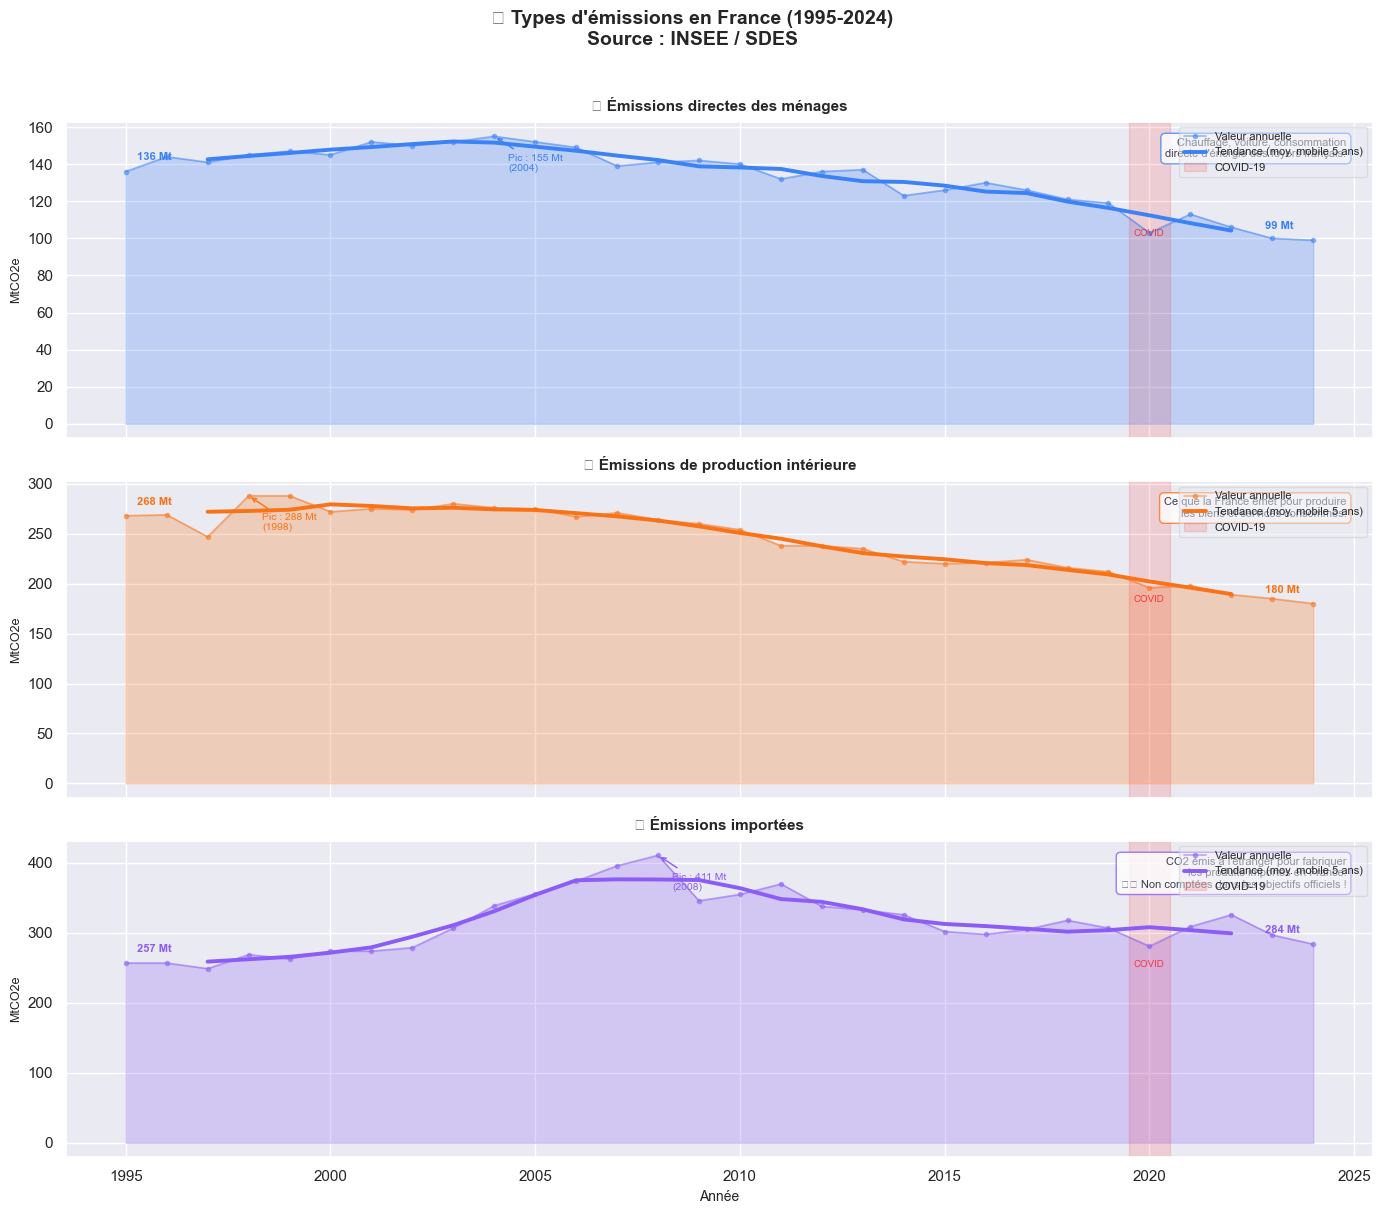

✅ Graphique sauvegardé → data/emissions_par_type.png
✅ CSV enrichi sauvegardé → data/emissions_par_type.csv


In [6]:
# src/emissions_par_type.py
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import io

# ── Données intégrées ──
data = """annee,emissions_directes_menages_MtCO2e,emissions_production_interieure_MtCO2e,emissions_importees_MtCO2e
1995,136,268,257
1996,144,269,257
1997,141,247,249
1998,145,288,269
1999,147,288,263
2000,145,272,274
2001,152,275,274
2002,150,274,279
2003,152,280,307
2004,155,276,339
2005,152,275,356
2006,149,267,374
2007,139,271,396
2008,141,264,411
2009,142,260,346
2010,140,254,355
2011,132,238,370
2012,136,238,338
2013,137,235,333
2014,123,222,326
2015,126,220,302
2016,130,221,298
2017,126,224,305
2018,121,216,318
2019,119,212,307
2020,103,196,281
2021,113,198,309
2022,106,189,326
2023,100,185,297
2024,99,180,284"""

# ── Chargement & renommage ──
df = pd.read_csv(io.StringIO(data))
df = df.rename(columns={
    "annee"                                  : "YYYY",
    "emissions_directes_menages_MtCO2e"      : "DIRECTES",
    "emissions_production_interieure_MtCO2e" : "PRODUCTION",
    "emissions_importees_MtCO2e"             : "IMPORTEES"
})

# ── Calculs enrichis ──

# Total des 3 types par année
df["TOTAL"] = df["DIRECTES"] + df["PRODUCTION"] + df["IMPORTEES"]

# Part de chaque type en % du total
df["PCT_DIRECTES"]   = (df["DIRECTES"]   / df["TOTAL"] * 100).round(1)
df["PCT_PRODUCTION"] = (df["PRODUCTION"] / df["TOTAL"] * 100).round(1)
df["PCT_IMPORTEES"]  = (df["IMPORTEES"]  / df["TOTAL"] * 100).round(1)

# Moyennes mobiles 5 ans pour chaque type
df["MOY5_DIRECTES"]   = df["DIRECTES"].rolling(5,   center=True).mean()
df["MOY5_PRODUCTION"] = df["PRODUCTION"].rolling(5, center=True).mean()
df["MOY5_IMPORTEES"]  = df["IMPORTEES"].rolling(5,  center=True).mean()

# ── Résumé console ──
print("📊 Résumé émissions par type :")
print(f"   Période : {df['YYYY'].min()} → {df['YYYY'].max()}")
print(f"\n   Émissions directes ménages :")
print(f"     1995 : {df['DIRECTES'].iloc[0]} MtCO2e → 2024 : {df['DIRECTES'].iloc[-1]} MtCO2e")
print(f"     Baisse : -{df['DIRECTES'].iloc[0] - df['DIRECTES'].iloc[-1]} Mt ({((df['DIRECTES'].iloc[0] - df['DIRECTES'].iloc[-1]) / df['DIRECTES'].iloc[0] * 100):.0f}%)")
print(f"\n   Émissions production intérieure :")
print(f"     1995 : {df['PRODUCTION'].iloc[0]} MtCO2e → 2024 : {df['PRODUCTION'].iloc[-1]} MtCO2e")
print(f"     Baisse : -{df['PRODUCTION'].iloc[0] - df['PRODUCTION'].iloc[-1]} Mt ({((df['PRODUCTION'].iloc[0] - df['PRODUCTION'].iloc[-1]) / df['PRODUCTION'].iloc[0] * 100):.0f}%)")
print(f"\n   Émissions importées :")
print(f"     1995 : {df['IMPORTEES'].iloc[0]} MtCO2e → 2024 : {df['IMPORTEES'].iloc[-1]} MtCO2e")
print(f"     Variation : {df['IMPORTEES'].iloc[-1] - df['IMPORTEES'].iloc[0]:+} Mt")

# ── Visualisation : 3 graphiques empilés ──
sns.set_theme(style="darkgrid")
fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

configs = [
    # (colonne,        moyenne mobile,      couleur,    titre,                                    contexte)
    ("DIRECTES",   "MOY5_DIRECTES",   "#3b82f6",  "🏠 Émissions directes des ménages",      
     "Chauffage, voiture, consommation\ndirecte d'énergie des foyers français."),
    
    ("PRODUCTION", "MOY5_PRODUCTION", "#f97316",  "🏭 Émissions de production intérieure",   
     "Ce que la France émet pour produire\nles biens et services consommés."),
    
    ("IMPORTEES",  "MOY5_IMPORTEES",  "#8b5cf6",  "🚢 Émissions importées",                  
     "CO2 émis à l'étranger pour fabriquer\nles produits importés en France.\n⚠️ Non comptées dans les objectifs officiels !"),
]

for ax, (col, moy_col, couleur, titre, contexte) in zip(axes, configs):

    # ── Aire remplie sous la courbe ──
    # Crée un effet visuel de "volume" — on voit l'ampleur des émissions
    ax.fill_between(df["YYYY"], df[col],
                    alpha=0.25, color=couleur)

    # ── Courbe brute ──
    # Les valeurs réelles année par année
    ax.plot(df["YYYY"], df[col],
            color=couleur, linewidth=1.2, alpha=0.5,
            marker="o", markersize=3,   # Petits points sur chaque année
            label="Valeur annuelle")

    # ── Moyenne mobile 5 ans ──
    # Lisse les variations pour voir la TENDANCE de fond
    # rolling(5, center=True) = moyenne de [année-2, année-1, année, année+1, année+2]
    ax.plot(df["YYYY"], df[moy_col],
            color=couleur, linewidth=2.8,
            label="Tendance (moy. mobile 5 ans)")

    # ── Annotations valeurs clés ──
    # Première valeur (1995)
    ax.annotate(f"{df[col].iloc[0]} Mt",
                xy=(df["YYYY"].iloc[0], df[col].iloc[0]),
                xytext=(8, 8), textcoords="offset points",
                fontsize=8, color=couleur, fontweight="bold")

    # Dernière valeur (2024)
    ax.annotate(f"{df[col].iloc[-1]} Mt",
                xy=(df["YYYY"].iloc[-1], df[col].iloc[-1]),
                xytext=(-35, 8), textcoords="offset points",
                fontsize=8, color=couleur, fontweight="bold")

    # Pic maximum
    idx_max = df[col].idxmax()
    ax.annotate(
        f"Pic : {df.loc[idx_max, col]} Mt\n({df.loc[idx_max, 'YYYY']})",
        xy=(df.loc[idx_max, "YYYY"], df.loc[idx_max, col]),
        xytext=(10, -25), textcoords="offset points",
        fontsize=7.5, color=couleur,
        arrowprops=dict(arrowstyle="->", color=couleur, lw=1)
    )

    # ── Zone COVID ──
    # Mise en évidence de la chute de 2020
    ax.axvspan(2019.5, 2020.5,
               alpha=0.12, color="red",
               label="COVID-19")
    ax.text(2019.6, df[col].min() + 2,
            "COVID", fontsize=7, color="red", alpha=0.7)

    # ── Texte de contexte dans le panneau ──
    ax.text(0.98, 0.95, contexte,
            transform=ax.transAxes,
            fontsize=8, va="top", ha="right",
            color="#374151",
            bbox=dict(boxstyle="round,pad=0.4",
                      facecolor="white",
                      edgecolor=couleur,
                      alpha=0.8))

    ax.set_title(titre, fontsize=11, fontweight="bold", pad=8)
    ax.set_ylabel("MtCO2e", fontsize=9)
    ax.legend(loc="upper right", fontsize=8, framealpha=0.5)

axes[-1].set_xlabel("Année", fontsize=10)

# ── Titre global ──
fig.suptitle(
    "🌍 Types d'émissions en France (1995-2024)\nSource : INSEE / SDES",
    fontsize=14, fontweight="bold", y=1.01
)

plt.tight_layout()
plt.savefig("data/emissions_par_type.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Graphique sauvegardé → data/emissions_par_type.png")

# ── Export CSV enrichi ──
df.to_csv("data/emissions_par_type.csv", index=False, sep=";")
print("✅ CSV enrichi sauvegardé → data/emissions_par_type.csv")

/var/folders/1m/b1tgmj252qxb80_71bh1dgbm0000gn/T/ipykernel_4495/719864701.py:111: UserWarning: Glyph 127968 (\N{HOUSE BUILDING}) missing from font(s) Arial.
  plt.savefig("data/emissions_par_type_final.png", dpi=150, bbox_inches="tight")
/var/folders/1m/b1tgmj252qxb80_71bh1dgbm0000gn/T/ipykernel_4495/719864701.py:111: UserWarning: Glyph 127981 (\N{FACTORY}) missing from font(s) Arial.
  plt.savefig("data/emissions_par_type_final.png", dpi=150, bbox_inches="tight")
/var/folders/1m/b1tgmj252qxb80_71bh1dgbm0000gn/T/ipykernel_4495/719864701.py:111: UserWarning: Glyph 128674 (\N{SHIP}) missing from font(s) Arial.
  plt.savefig("data/emissions_par_type_final.png", dpi=150, bbox_inches="tight")
/var/folders/1m/b1tgmj252qxb80_71bh1dgbm0000gn/T/ipykernel_4495/719864701.py:111: UserWarning: Glyph 127757 (\N{EARTH GLOBE EUROPE-AFRICA}) missing from font(s) Arial.
  plt.savefig("data/emissions_par_type_final.png", dpi=150, bbox_inches="tight")
/Users/matteocherief/Desktop/hackathon_data_sdv/venv/l

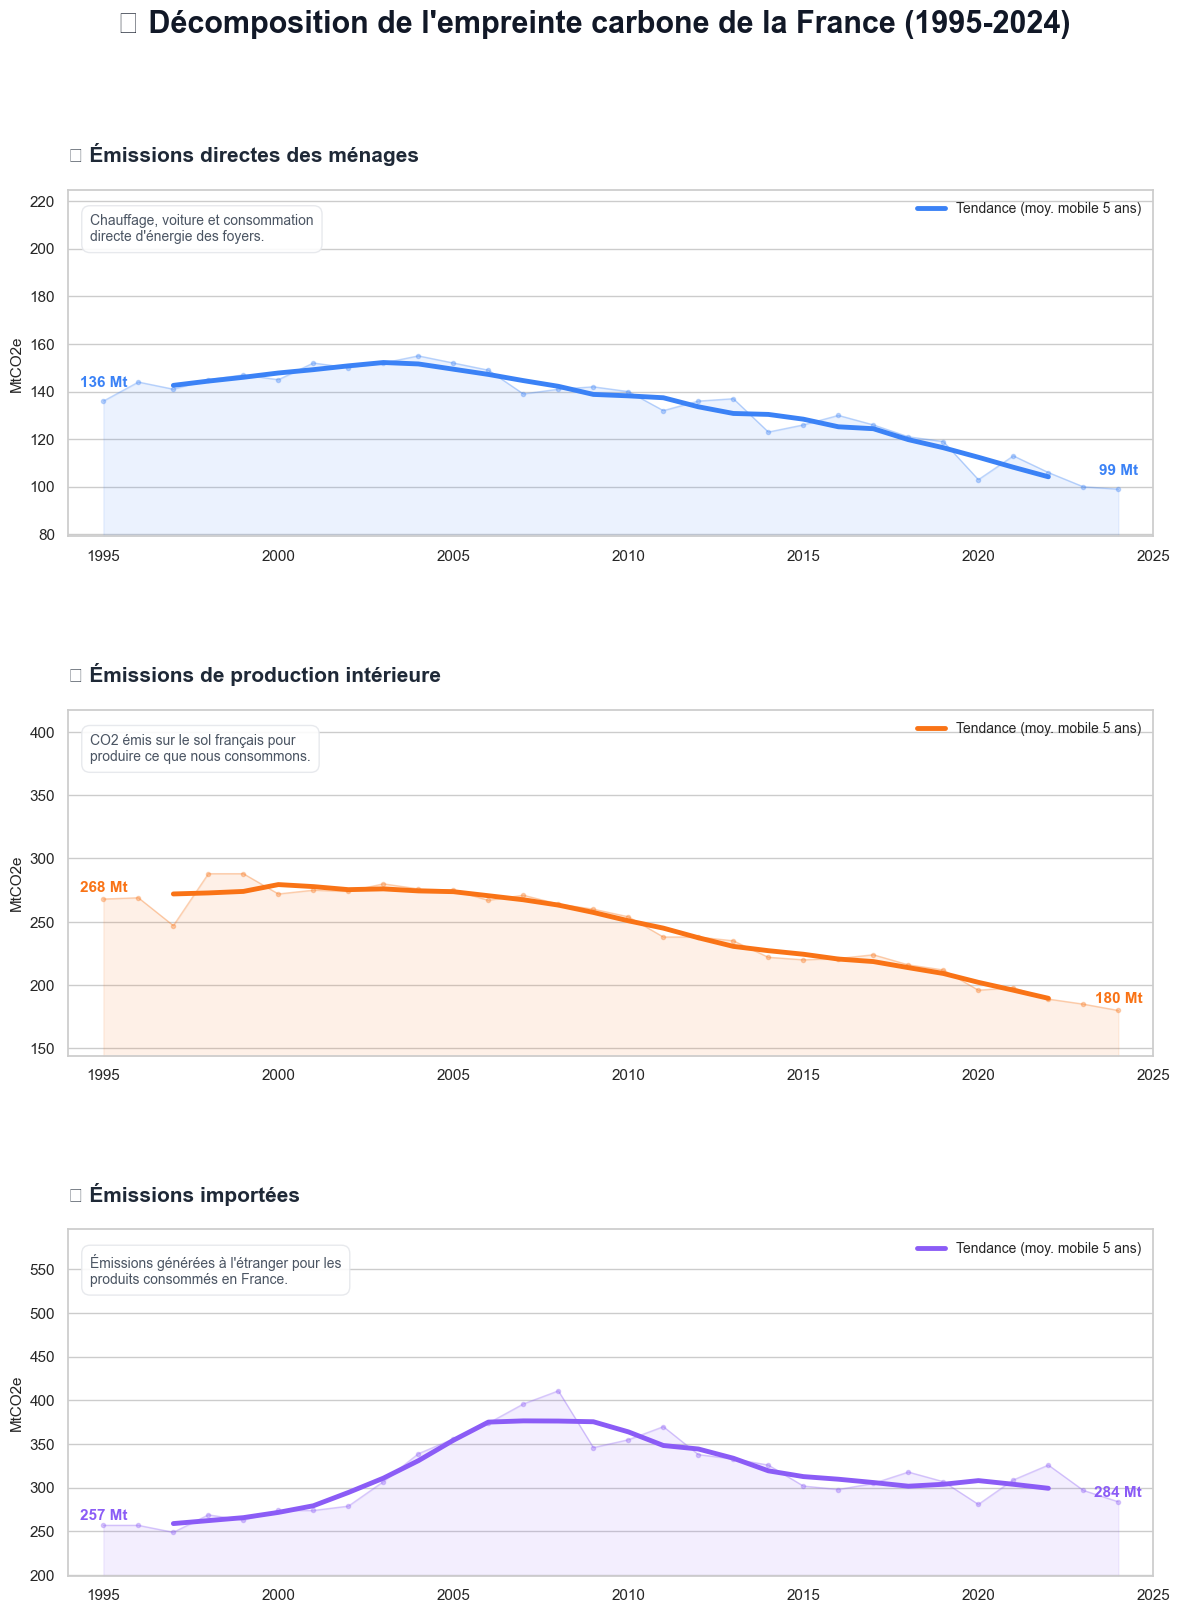

✅ Graphique final généré avec années tous les 5 ans.


In [10]:
# src/emissions_par_type.py
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import io

# ── 1. Données intégrées ──
data = """annee,emissions_directes_menages_MtCO2e,emissions_production_interieure_MtCO2e,emissions_importees_MtCO2e
1995,136,268,257
1996,144,269,257
1997,141,247,249
1998,145,288,269
1999,147,288,263
2000,145,272,274
2001,152,275,274
2002,150,274,279
2003,152,280,307
2004,155,276,339
2005,152,275,356
2006,149,267,374
2007,139,271,396
2008,141,264,411
2009,142,260,346
2010,140,254,355
2011,132,238,370
2012,136,238,338
2013,137,235,333
2014,123,222,326
2015,126,220,302
2016,130,221,298
2017,126,224,305
2018,121,216,318
2019,119,212,307
2020,103,196,281
2021,113,198,309
2022,106,189,326
2023,100,185,297
2024,99,180,284"""

# ── 2. Préparation des données ──
df = pd.read_csv(io.StringIO(data))
df = df.rename(columns={
    "annee": "YYYY",
    "emissions_directes_menages_MtCO2e": "DIRECTES",
    "emissions_production_interieure_MtCO2e": "PRODUCTION",
    "emissions_importees_MtCO2e": "IMPORTEES"
})

# Calcul des moyennes mobiles
for col in ["DIRECTES", "PRODUCTION", "IMPORTEES"]:
    df[f"MOY5_{col}"] = df[col].rolling(5, center=True).mean()

# ── 3. Visualisation (Design Aéré & Années tous les 5 ans) ──
sns.set_theme(style="whitegrid")
# figsize=(14, 18) pour donner beaucoup de hauteur
fig, axes = plt.subplots(3, 1, figsize=(14, 18)) 

configs = [
    ("DIRECTES", "MOY5_DIRECTES", "#3b82f6", "🏠 Émissions directes des ménages", 
     "Chauffage, voiture et consommation\ndirecte d'énergie des foyers."),
    ("PRODUCTION", "MOY5_PRODUCTION", "#f97316", "🏭 Émissions de production intérieure", 
     "CO2 émis sur le sol français pour\nproduire ce que nous consommons."),
    ("IMPORTEES", "MOY5_IMPORTEES", "#8b5cf6", "🚢 Émissions importées", 
     "Émissions générées à l'étranger pour les\nproduits consommés en France.")
]

for ax, (col, moy_col, couleur, titre, contexte) in zip(axes, configs):
    
    # --- ESPACEMENT VERTICAL (Ciel du graphique) ---
    ax.set_ylim(df[col].min() * 0.8, df[col].max() * 1.45)

    # --- TRACÉ ---
    ax.fill_between(df["YYYY"], df[col], alpha=0.1, color=couleur)
    ax.plot(df["YYYY"], df[col], color=couleur, linewidth=1, alpha=0.3, marker="o", markersize=3)
    ax.plot(df["YYYY"], df[moy_col], color=couleur, linewidth=3.5, label="Tendance (moy. mobile 5 ans)")

    # --- CONFIGURATION AXE X (Années tous les 5 ans) ---
    annees_ticks = range(1995, 2026, 5) # Génère 1995, 2000, 2005, 2010, 2015, 2020, 2025
    ax.set_xticks(annees_ticks)
    ax.set_xticklabels(annees_ticks, fontsize=11, fontweight="500")
    ax.set_xlim(1994, 2025)

    # --- ANNOTATIONS ---
    # Valeurs 1995 et 2024
    for idx, label in zip([0, -1], ["1995", "2024"]):
        val = df[col].iloc[idx]
        ax.text(df["YYYY"].iloc[idx], val + 6, f"{int(val)} Mt", 
                color=couleur, fontweight="bold", ha='center', fontsize=11)

    # Boîte de contexte
    ax.text(0.02, 0.93, contexte, transform=ax.transAxes, fontsize=10, 
            va="top", ha="left", color="#4b5563",
            bbox=dict(boxstyle="round,pad=0.6", facecolor="white", edgecolor="#e5e7eb", alpha=0.9))

    # --- STYLE ---
    ax.set_title(titre, fontsize=15, fontweight="bold", loc='left', pad=20, color="#1f2937")
    ax.set_ylabel("MtCO2e", fontsize=11)
    ax.legend(loc="upper right", frameon=False, fontsize=10)
    ax.xaxis.grid(False) # Épure le fond

# --- AJUSTEMENTS FINAUX ---
fig.suptitle(
    "🌍 Décomposition de l'empreinte carbone de la France (1995-2024)\n",
    fontsize=22, fontweight="bold", y=0.98, color="#111827"
)

# hspace=0.5 pour que l'axe X du haut ne touche pas le titre du bas
plt.subplots_adjust(hspace=0.5) 

# Sauvegarde
plt.savefig("data/emissions_par_type_final.png", dpi=150, bbox_inches="tight")
plt.show()

print("✅ Graphique final généré avec années tous les 5 ans.")